# MCDI505 — Sumativa 01
## Análisis exploratorio del consumo eléctrico del litoral

**Estudiante:** Luis Rodrigo Espinoza Muñoz  
**Docente:** Dr. Harvey Jezlid Rosas Quintero  
  
**Fecha:** 04 de octubre de 2026  
**Datos originales:** `data/raw/consumo_electrico_litoral.csv` (desde la raíz del proyecto)  
**Figuras:** `results/figures/` (desde la raíz del proyecto)



## 1. Introducción y objetivos


### 1.1 Objetivo general y objetivos específicos

En este trabajo analizo el consumo mensual, sus componentes y su relación con la ACF y la PACF. El objetivo es reconocer los patrones de la serie como base para modelar más adelante.

Sigo los criterios de la Sumativa 1 (Universidad Andrés Bello, s. f.-c). No incluyo observaciones específicas del docente, porque no fueron proporcionadas.


## 2. Contexto del caso y descripción del dataset

### 2.1 Contexto organizacional y problema

La Distribuidora Eléctrica del Litoral (DEL) necesita anticipar el consumo comercial para contratar energía. Si contrata menos, debe comprar energía adicional; si contrata de más, paga por energía que no usa. Los datos del caso son sintéticos.

El caso informa una recalibración de medidores en noviembre de 2017, nuevos clientes por un centro comercial en abril de 2019 y restricciones sanitarias entre marzo de 2020 y diciembre de 2021. Uso estos antecedentes para interpretar los datos, aunque los gráficos por sí solos no confirman sus causas (Universidad Andrés Bello, s. f.-a).


### 2.2 Diccionario de variables y alcance

| Variable | Tipo | Unidad | Rol |
|---|---|---|---|
| `fecha` | Fecha | Mes | Índice temporal |
| `consumo_gwh` | Numérica continua | GWh | Variable objetivo |
| `clientes_comerciales` | Numérica discreta | Número de clientes | Covariable |
| `temperatura_media_c` | Numérica continua | °C | Covariable |
| `dias_habiles` | Numérica discreta | Días | Covariable |

Los datos incluyen 120 meses, de enero de 2015 a diciembre de 2024, con fechas al inicio de cada mes (MS). Analizo 2015–2023 y reservo 2024 para Semana 4. El enfoque es univariado: estudio el consumo y uso las tres covariables como contexto.


## 3. Carga, auditoría y preparación de los datos

### 3.1 Reproducibilidad del entorno y carga del dataset

El notebook está preparado para ejecutarse en orden mediante **Restart Kernel and Run All**. Se recomienda descargar o clonar el repositorio completo para disponer de `requirements.txt` y `data/raw/consumo_electrico_litoral.csv`. La instalación de las dependencias necesita Internet; una vez instaladas, el análisis utiliza el CSV local.

La raíz del proyecto se detecta automáticamente desde la carpeta principal, `notebooks/` o `notebooks/notebooks_sumativa/`. Se usan rutas con `pathlib`, compatibles con macOS, Windows y Linux. Todas las figuras se muestran dentro del notebook y se guardan como PNG en `results/figures/`.

**Instalación local en macOS o Linux (desde la raíz del repositorio):**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi505 --display-name "Python (MCDI505)"
jupyter lab
```

**Instalación local en Windows PowerShell (desde la raíz del repositorio):**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi505 --display-name "Python (MCDI505)"
jupyter lab
```

Si PowerShell bloquea la activación, ejecutar `Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass` y volver a activar el entorno. Seleccionar el kernel **Python (MCDI505)**, abrir `notebooks/notebooks_sumativa/mcdi505_s1lespinoza.ipynb` y ejecutar todas las celdas en orden. El entorno `.venv` se crea en cada computador; no se copia entre sistemas operativos.

**Google Colab:** subir el notebook y ejecutar primero en una celda adicional:

```python
%pip install pandas numpy matplotlib statsmodels
```

En el panel de archivos, crear `data/raw/` dentro del directorio de trabajo y subir allí `consumo_electrico_litoral.csv`. Luego ejecutar el notebook desde el inicio. No se necesita `.venv` ni registrar un kernel local. Al terminar, descargar el notebook ejecutado y las figuras de `results/figures/`, ya que los archivos del entorno de Colab son temporales. El CSV debe acompañar al notebook: no se ha configurado una fuente pública de respaldo.

**Alcance de la reproducibilidad:** el entorno local se ha validado en macOS con Python 3.10.4. Las instrucciones para Windows, Linux y Colab describen cómo prepararlo, pero no constituyen pruebas ejecutadas en esas plataformas. Se registran las versiones utilizadas en la siguiente celda; `requirements.txt` no fija versiones, por lo que una instalación futura puede usar versiones distintas. Para el error de SciPy `_spropack` / `__thread_bss` en macOS ARM64, consultar la solución específica del entorno Python 3.10 en `README.md`.

Cargo el CSV sin modificarlo. Analizo las 108 observaciones de 2015–2023 y reservo las 12 de 2024 para Semana 4. No necesito una semilla porque no uso procedimientos aleatorios. La interpolación corresponde al análisis exploratorio de 2015–2023; al modelar se deberá respetar el orden temporal y ajustar la preparación con el período de entrenamiento.


In [1]:
# importar las librerías
import sys
from IPython.display import display
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# localizar la raíz del proyecto
project_root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "data/raw/consumo_electrico_litoral.csv").is_file()),
    None,
)

# avisar si no se encuentra el archivo de datos
if project_root is None:
    raise FileNotFoundError(
        "Ejecuta el notebook dentro de la carpeta del proyecto que contiene data/raw/."
    )

# carpeta de salida para las figuras
output_dir = project_root / "results/figures"
output_dir.mkdir(parents=True, exist_ok=True)

# leer el CSV sin modificar el archivo original
data_path = project_root / "data/raw/consumo_electrico_litoral.csv"
df_original = pd.read_csv(
    data_path,
    parse_dates=["fecha"],
    index_col="fecha",
)

# separar el período de análisis y reservar 2024
df = df_original.loc[
    (df_original.index >= "2015-01-01")
    & (df_original.index < "2024-01-01")
].copy()

# dejar 2024 separado para la evaluación posterior
df_prueba = df_original.loc[
    (df_original.index >= "2024-01-01")
    & (df_original.index < "2025-01-01")
].copy()

# registrar las versiones utilizadas
print(f"Python={sys.version.split()[0]}")
print(f"pandas={pd.__version__}, numpy={np.__version__}")
print(f"matplotlib={matplotlib.__version__}, statsmodels={statsmodels.__version__}")

# configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# mostrar las primeras filas del período de análisis
display(df.head())
print(f"Observaciones para el análisis: {len(df)}")

# funciones usadas en las celdas siguientes
from statsmodels.tsa.stattools import acf, pacf

def mostrar_figura(fig, nombre):
    # ajustar los espacios y guardar el gráfico
    fig.tight_layout()
    fig.savefig(output_dir / nombre, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


Python=3.10.4
pandas=2.3.3, numpy=2.2.6
matplotlib=3.10.9, statsmodels=0.15.0


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
fecha,,,,
2015-01-01,108.32,41827,19.60,22
2015-02-01,94.71,41918,18.70,20
2015-03-01,89.52,42045,16.50,22
2015-04-01,82.24,42129,13.30,22
2015-05-01,82.60,42242,12.00,21


Observaciones para el análisis: 108


### 3.2 Auditoría de integridad temporal

El calendario de 2015–2023 está completo, ordenado y sin fechas duplicadas. Todas corresponden al inicio del mes. Las comprobaciones no detectaron infinitos, consumos no positivos ni otros valores inválidos.

Falta el consumo de agosto de 2016, febrero de 2019 y junio de 2022. Las fechas sí existen; faltan sus valores. Las demás variables están completas.

Los 105 consumos disponibles tienen una media de 102,85 GWh, desviación de 12,67 GWh y valores entre 73,19 y 133,58 GWh. La tabla también resume las covariables.


In [2]:
# revisar el índice temporal sin ordenar ni modificar los datos
indice = df.index

if df.empty or indice.isna().any():
    raise ValueError("Revisa los datos: el período está vacío o hay fechas nulas.")

# calendario mensual esperado para el período de análisis
calendario = pd.date_range("2015-01-01", "2023-12-01", freq="MS")

# identificar meses ausentes y fechas fuera del calendario
fechas_ausentes = calendario.difference(indice)
fechas_fuera = indice.difference(calendario)

# mostrar los resultados de la auditoría temporal
print("Índice ordenado:", indice.is_monotonic_increasing)
print("Índice sin duplicados:", indice.is_unique)
print("Todas las fechas son inicio de mes:", indice.is_month_start.all())
print("Meses ausentes:", fechas_ausentes.strftime("%Y-%m").tolist())
print("Fechas fuera del calendario:", fechas_fuera.tolist())

# comprobar que esté cada mes una sola vez
calendario_completo = (
    indice.is_unique
    and len(fechas_ausentes) == 0
    and len(fechas_fuera) == 0
)
print("Calendario mensual completo:", calendario_completo)

# mostrar valores faltantes por variable
print("\nValores faltantes:")
display(df.isna().sum().to_frame("cantidad"))

# mostrar los meses registrados que no tienen consumo
print("\nMeses con consumo faltante:")
display(df.loc[df["consumo_gwh"].isna()])

# revisar valores infinitos en las variables numéricas
numericas = df.select_dtypes(include="number")
print("\nValores infinitos:")
display(np.isinf(numericas).sum().to_frame("cantidad"))

# revisar valores que requieren investigación
revision = pd.Series({
    "Consumo no positivo": (df["consumo_gwh"] <= 0).sum(),
    "Clientes no positivos": (df["clientes_comerciales"] <= 0).sum(),
    "Días hábiles fuera de 0–31": (
        (df["dias_habiles"] < 0) | (df["dias_habiles"] > 31)
    ).sum(),
    "Clientes con valores no enteros": (
        df["clientes_comerciales"].dropna() % 1 != 0
    ).sum(),
    "Días hábiles con valores no enteros": (
        df["dias_habiles"].dropna() % 1 != 0
    ).sum(),
})

print("\nValores que requieren revisión:")
display(revision.to_frame("cantidad"))

# mostrar las estadísticas de los datos sin imputar
print("\nEstadísticas descriptivas:")
display(numericas.describe().T)

Índice ordenado: True
Índice sin duplicados: True
Todas las fechas son inicio de mes: True
Meses ausentes: []
Fechas fuera del calendario: []
Calendario mensual completo: True

Valores faltantes:


,cantidad
consumo_gwh,3
clientes_comerciales,0
temperatura_media_c,0
dias_habiles,0



Meses con consumo faltante:


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
fecha,,,,
2016-08-01,NaN,43972,11.50,23
2019-02-01,NaN,47466,18.40,20
2022-06-01,NaN,53449,12.10,22



Valores infinitos:


,cantidad
consumo_gwh,0
clientes_comerciales,0
temperatura_media_c,0
dias_habiles,0



Valores que requieren revisión:


,cantidad
Consumo no positivo,0
Clientes no positivos,0
Días hábiles fuera de 0–31,0
Clientes con valores no enteros,0
Días hábiles con valores no enteros,0



Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
consumo_gwh,105.00,102.85,12.67,73.19,94.71,101.31,111.08,133.58
clientes_comerciales,108.00,48634.68,4191.69,41827.00,44891.75,48952.50,52340.75,55436.00
temperatura_media_c,108.00,15.59,3.20,10.50,12.50,15.30,18.40,21.70
dias_habiles,108.00,21.73,0.94,20.00,21.00,22.00,22.00,23.00


### 3.3 Comparación y elección de imputación — Decisión 1.1

Comparo dos opciones: interpolar entre meses vecinos según la distancia temporal, o usar el mismo mes del año anterior ajustado por el cambio interanual del mes previo.

| Hueco | Temporal (GWh) | Estacional ajustada (GWh) | Elección y motivo |
|---|---:|---:|---|
| Agosto de 2016 | 95,86 | 94,87 | Temporal: sigue la baja entre julio y septiembre. Ambas opciones dan valores cercanos. |
| Febrero de 2019 | 116,34 | 114,18 | Temporal: representa la transición entre enero y marzo, con un valor similar al estacional. |
| Junio de 2022 | 101,43 | 103,86 | Temporal: sigue el aumento entre mayo y julio sin trasladar el nivel de junio de 2021, dentro de la ventana COVID informada. |

Elijo la interpolación temporal y conservo una copia de los valores originales. Su media y desviación son 102,90 y 12,58 GWh; con la opción estacional, 102,89 y 12,56 GWh. La tabla incluye la varianza y la ACF(1), que cambia poco. Decido según la ubicación de los huecos, no por una mayor autocorrelación.

La interpolación puede suavizar la serie y cambiar su dependencia. Aquí uso datos posteriores a cada hueco porque el análisis es retrospectivo. Para pronosticar, solo se debe usar la información disponible en cada fecha, sin incluir los datos de prueba.


,mes,temporal_gwh,estacional_gwh
fecha,,,
2016-08-01,8,95.86,94.87
2019-02-01,2,116.34,114.18
2022-06-01,6,101.43,103.86


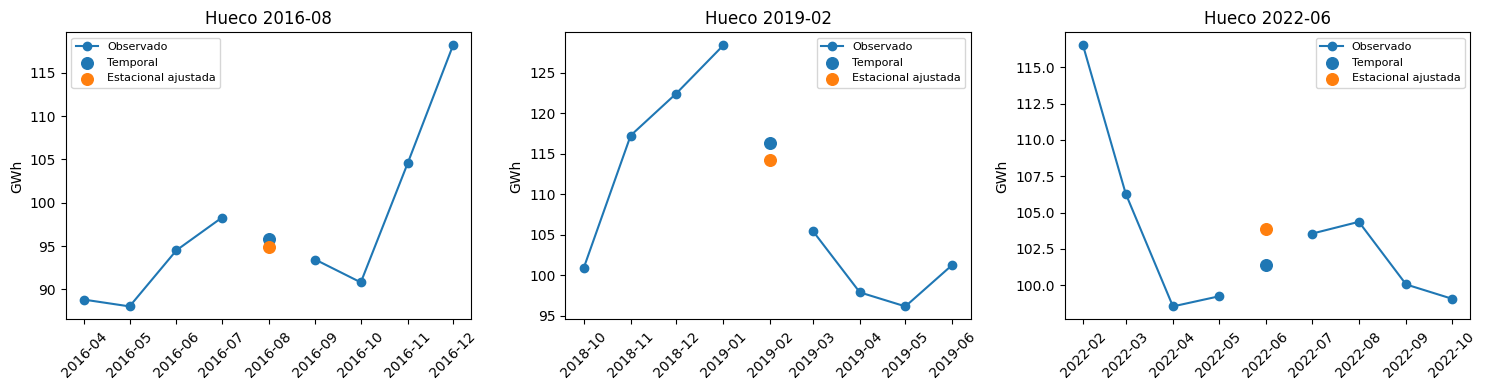

,media,desviacion,varianza,ACF_1
Temporal,102.90,12.58,158.18,0.74
Estacional ajustada,102.89,12.56,157.80,0.74


,diferencia
media,-0.01
desviacion,-0.01
varianza,-0.37
ACF_1,-0.00


Método utilizado: {'2016-08': 'Temporal', '2019-02': 'Temporal', '2022-06': 'Temporal'}


In [3]:
# conservar los valores observados
serie_original = df['consumo_gwh'].copy()
# ubicar los meses donde falta el consumo
huecos = serie_original.index[serie_original.isna()]
# rellenar los huecos según la distancia entre fechas
serie_temporal = serie_original.interpolate('time', limit_area='inside')
# calcular el cambio interanual del mes anterior
ajuste = serie_original.shift(1) / serie_original.shift(13)
# usar el mismo mes del año anterior con ese ajuste
serie_estacional = serie_original.fillna(serie_original.shift(12) * ajuste)
estrategias = {'Temporal': serie_temporal, 'Estacional ajustada': serie_estacional}
# comprobar que ambas opciones dejen valores válidos
for nombre, s in estrategias.items():
    if s.isna().any() or not np.isfinite(s).all() or (s <= 0).any():
        raise ValueError(f'Revisar estrategia {nombre}: quedan valores inválidos.')
# comparar los valores propuestos para cada hueco
comparacion = pd.DataFrame({
    'mes': huecos.month,
    'temporal_gwh': serie_temporal.loc[huecos].to_numpy(),
    'estacional_gwh': serie_estacional.loc[huecos].to_numpy(),
}, index=huecos)
display(comparacion)
# mirar los meses cercanos a cada dato faltante
if len(huecos):
    fig, axes = plt.subplots(1, len(huecos), figsize=(5*len(huecos), 4), squeeze=False)
    for ax, fecha in zip(axes.ravel(), huecos):
        tramo = serie_original.loc[fecha-pd.DateOffset(months=4):fecha+pd.DateOffset(months=4)]
        ax.plot(tramo.index, tramo, 'o-', label='Observado')
        for nombre, s in estrategias.items():
            ax.scatter(fecha, s.loc[fecha], s=70, label=nombre)
        ax.set(title=f'Hueco {fecha:%Y-%m}', ylabel='GWh')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8)
    mostrar_figura(fig, 's1_imputaciones.png')
# revisar cuánto cambian las estadísticas con cada opción
resumen_imputacion = pd.DataFrame({nombre: {
    'media': s.mean(), 'desviacion': s.std(), 'varianza': s.var(),
    'ACF_1': acf(s, nlags=1, fft=False)[1],
} for nombre, s in estrategias.items()}).T
display(resumen_imputacion)
display((resumen_imputacion.loc['Estacional ajustada'] - resumen_imputacion.loc['Temporal']).to_frame('diferencia'))

# usar la imputación temporal justificada en 3.3
metodo_por_hueco = {fecha: 'Temporal' for fecha in huecos}
serie = serie_original.copy()
for fecha, metodo in metodo_por_hueco.items():
    serie.loc[fecha] = estrategias[metodo].loc[fecha]
print('Método utilizado:', {f.strftime('%Y-%m'): m for f, m in metodo_por_hueco.items()})


## 4. Exploración y visualización de la serie — ID 1.1

### 4.1 Gráfico temporal y evolución del nivel

Observo un aumento general: la media anual pasa de 90,78 GWh en 2015 a 113,66 GWh en 2023. El crecimiento se interrumpe en 2020, cuando cae a 95,49 GWh, y luego sube a 102,15 en 2021 y 107,11 en 2022.

La media móvil de 12 meses ayuda a ver los cambios de nivel. También marco los tres valores imputados y los eventos del caso. Esta trayectoria no basta para demostrar una tendencia determinista.


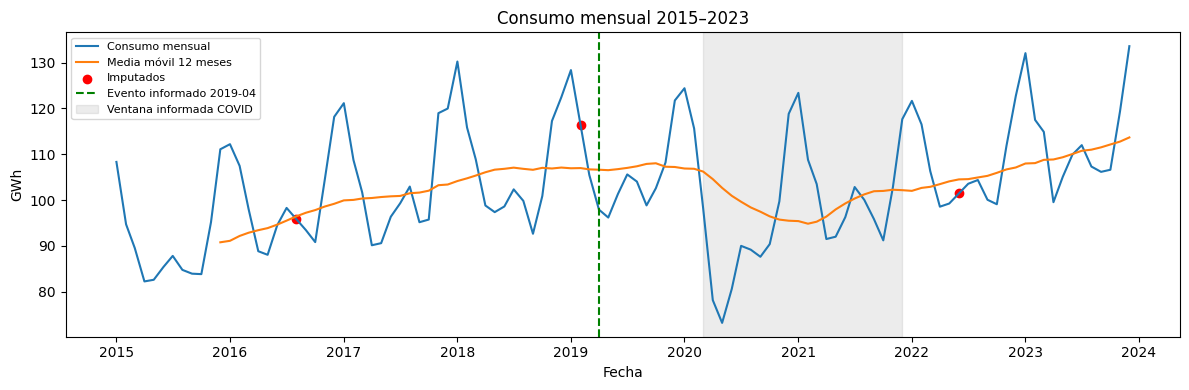

,mean,min,max
año,,,
2015,90.78,82.24,111.08
2016,99.18,88.05,118.16
2017,103.39,90.13,121.14
2018,107.09,92.64,130.23
2019,107.21,96.18,128.36
2020,95.49,73.19,124.40
2021,102.15,91.20,123.39
2022,107.11,98.55,122.71
2023,113.66,99.53,133.58


In [4]:
# serie y media móvil: distinguir valores imputados
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie, label='Consumo mensual')
# suavizar las variaciones con el promedio de 12 meses
ax.plot(serie.rolling(12).mean(), label='Media móvil 12 meses')
ax.scatter(huecos, serie.loc[huecos], color='red', label='Imputados')
# marcar los eventos informados en el caso
ax.axvline(pd.Timestamp('2019-04-01'), color='green', linestyle='--', label='Evento informado 2019-04')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), alpha=.15, color='gray', label='Ventana informada COVID')
ax.set(xlabel='Fecha', ylabel='GWh', title='Consumo mensual 2015–2023')
ax.legend(fontsize=8)
mostrar_figura(fig, 's1_serie.png')
# resumir el consumo de cada año
display(serie.groupby(serie.index.year).agg(['mean','min','max']).rename_axis('año'))


### 4.2 Perfil estacional y superposición anual — Decisión 1.4

El consumo promedio es mayor en enero (122,41 GWh) y diciembre (120,68 GWh), y menor en abril y mayo (cerca de 91,7 GWh). Julio tiene un máximo local de 100,18 GWh frente a junio y agosto. Son dos máximos dentro del mismo patrón anual.

Al superponer los años, observo la repetición cada 12 meses y la caída de 2020. Identifico estacionalidad anual, pero no un ciclo plurianual: una caída y recuperación aisladas no bastan para afirmarlo (Hyndman & Athanasopoulos, 2021).


,mean,std,min,max
mes,,,,
1,122.41,7.90,108.32,132.06
2,111.28,7.36,94.71,117.49
3,102.94,7.29,89.52,114.88
4,91.74,7.76,78.15,99.53
5,91.59,9.54,73.19,105.07
6,96.04,8.73,80.60,109.91
7,100.18,7.52,87.81,111.98
8,98.70,7.49,84.76,107.31
9,94.85,6.62,83.93,106.15


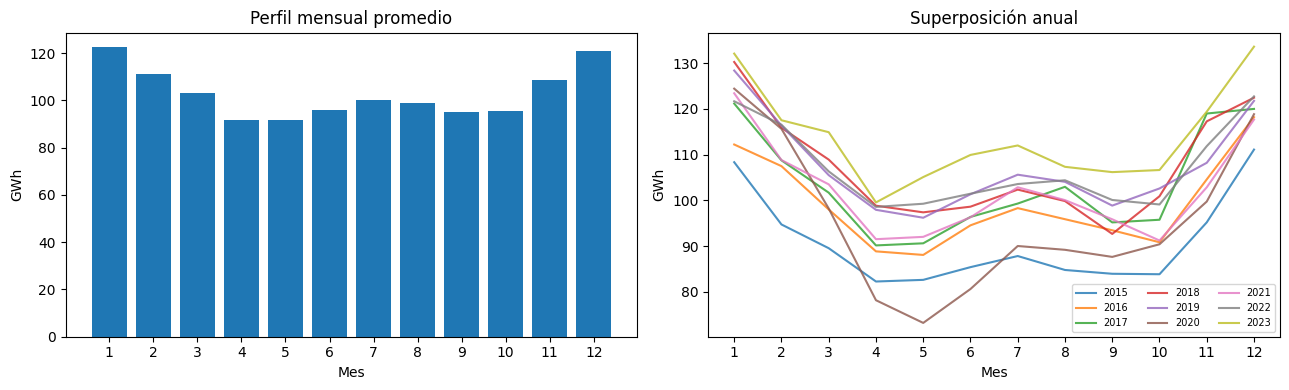

In [5]:
# perfil de consumo por mes y superposición anual
perfil = serie.groupby(serie.index.month).agg(['mean', 'std', 'min', 'max'])
perfil.index.name = 'mes'
display(perfil)
# mostrar el promedio mensual junto a las curvas de cada año
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(perfil.index, perfil['mean'])
axes[0].set(title='Perfil mensual promedio', xlabel='Mes', ylabel='GWh', xticks=range(1,13))
# comparar los años usando los mismos meses
for anio, grupo in serie.groupby(serie.index.year):
    axes[1].plot(grupo.index.month, grupo, label=str(anio), alpha=.8)
axes[1].set(title='Superposición anual', xlabel='Mes', ylabel='GWh', xticks=range(1,13))
axes[1].legend(ncol=3, fontsize=7)
mostrar_figura(fig, 's1_estacionalidad.png')

### 4.3 Variabilidad y amplitud estacional

El nivel y la dispersión cambian con el tiempo. La amplitud anual pasa de 28,84 GWh en 2015 a 34,05 GWh en 2023, equivalentes al 31,77 % y 29,96 % de sus medias.

En varios años la amplitud relativa ronda el 30 %, lo que apoya el esquema multiplicativo. Hay excepciones: 22,56 % en 2022 y 53,63 % en 2020. Este último combina estacionalidad y perturbación, por lo que no lo uso solo para elegir el método.


,mean,std,min,max,amplitud_gwh,amplitud_relativa_pct,cv_pct
fecha,,,,,,,
2015,90.78,9.84,82.24,111.08,28.84,31.77,10.84
2016,99.18,9.51,88.05,118.16,30.11,30.36,9.59
2017,103.39,11.27,90.13,121.14,31.01,29.99,10.90
2018,107.09,11.72,92.64,130.23,37.59,35.10,10.95
2019,107.21,9.97,96.18,128.36,32.18,30.02,9.30
2020,95.49,16.48,73.19,124.40,51.21,53.63,17.26
2021,102.15,10.24,91.20,123.39,32.19,31.51,10.02
2022,107.11,8.88,98.55,122.71,24.16,22.56,8.29
2023,113.66,10.54,99.53,133.58,34.05,29.96,9.27


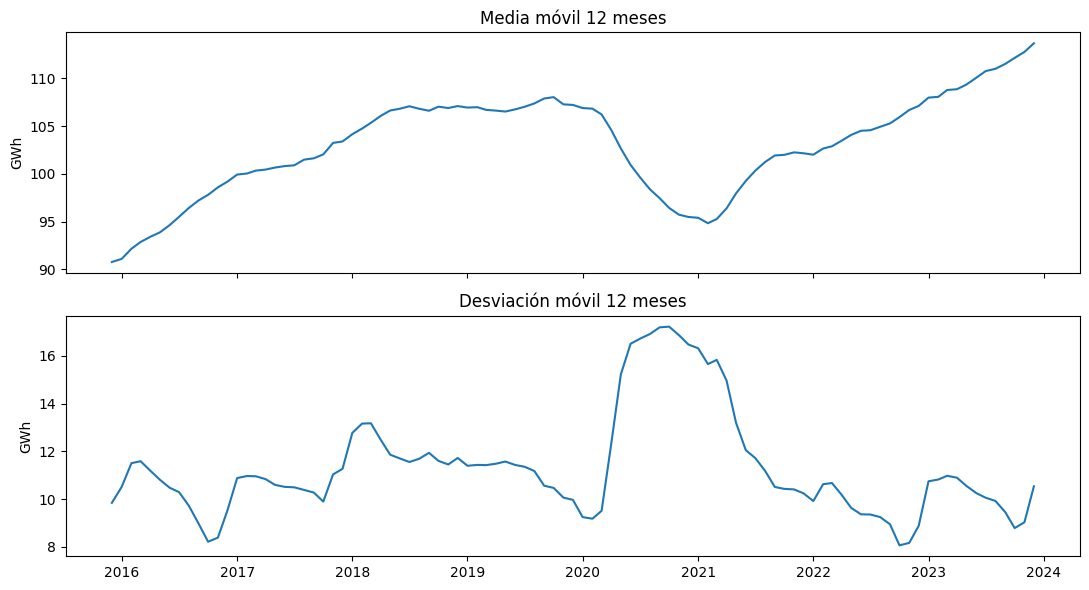

In [6]:
# dispersión móvil y amplitudes: evidencia para elegir el esquema
anual = serie.groupby(serie.index.year)
amplitudes = anual.agg(['mean', 'std', 'min', 'max'])
# calcular la diferencia entre el máximo y el mínimo anual
amplitudes['amplitud_gwh'] = amplitudes['max'] - amplitudes['min']
# expresar la amplitud como porcentaje del promedio
amplitudes['amplitud_relativa_pct'] = 100 * amplitudes['amplitud_gwh'] / amplitudes['mean']
# comparar la dispersión respecto al nivel de consumo
amplitudes['cv_pct'] = 100 * amplitudes['std'] / amplitudes['mean']
display(amplitudes)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(serie.rolling(12).mean()); axes[0].set(ylabel='GWh', title='Media móvil 12 meses')
axes[1].plot(serie.rolling(12).std()); axes[1].set(ylabel='GWh', title='Desviación móvil 12 meses')
mostrar_figura(fig, 's1_variabilidad.png')

## 5. Atípicos, acontecimientos y covariables

### 5.1 Dato atípico de noviembre de 2017 — Decisión 1.2

Noviembre de 2017 registra 118,96 GWh y un aumento interanual de 13,77 %. El caso informa una recalibración de medidores, por eso lo comparo con 2016 y 2018.

Su variación está a 1,34 desviaciones estándar de la media del resto. No es un extremo fuerte con esta medida, que también incluye el período COVID, pero el antecedente de medición sigue siendo relevante.

Conservo y marco el dato, sin asumir que refleja el consumo real. Reemplazarlo por el promedio de noviembre de 2016 y 2018 bajaría la media en 0,075 GWh y la varianza en 1,818 GWh². Como tampoco conozco el valor verdadero, no lo reemplazo y dejo la anomalía identificada para la siguiente etapa.


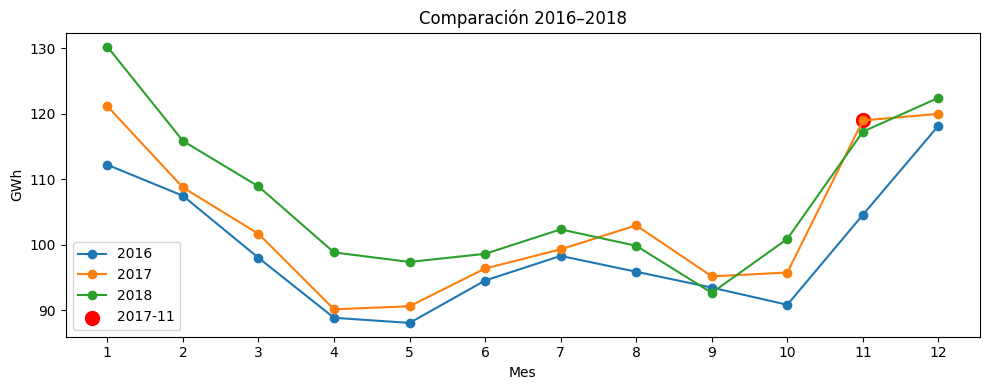

,valor
consumo_gwh,118.96
variacion_interanual_pct,13.77
z_interanual_resto,1.34


,media,varianza
Conservar,102.90,158.18
Ajuste con años vecinos,102.82,156.36


,cambio
media,-0.07
varianza,-1.82


In [7]:
# aislar noviembre 2017 frente a los años vecinos
fig, ax = plt.subplots(figsize=(10, 4))
for anio in (2016, 2017, 2018):
    s = serie.loc[str(anio)]
    ax.plot(s.index.month, s, 'o-', label=str(anio))
ax.scatter(11, serie.loc['2017-11-01'], color='red', s=100, label='2017-11')
ax.set(xlabel='Mes', ylabel='GWh', xticks=range(1,13), title='Comparación 2016–2018')
ax.legend()
mostrar_figura(fig, 's1_atipico.png')
# comparar cada consumo con el del mismo mes del año anterior
variacion_interanual = 100 * (serie / serie.shift(12) - 1)
fecha_atipico = pd.Timestamp('2017-11-01')
# usar las demás variaciones como referencia
resto = variacion_interanual.drop(index=fecha_atipico).dropna()
# medir qué tan lejos queda noviembre de 2017 del resto
z_interanual = (variacion_interanual.loc[fecha_atipico] - resto.mean()) / resto.std()
display(pd.Series({'consumo_gwh': serie.loc[fecha_atipico],
    'variacion_interanual_pct': variacion_interanual.loc[fecha_atipico],
    'z_interanual_resto': z_interanual}).to_frame('valor'))
# alternativa de ajuste solo para comparar; no sobrescribe la serie
valor_alternativo = (serie.loc['2016-11-01'] + serie.loc['2018-11-01']) / 2
serie_ajustada = serie.copy()
serie_ajustada.loc[fecha_atipico] = valor_alternativo
# revisar cuánto cambiarían la media y la varianza
impacto_atipico = pd.DataFrame({
    'Conservar': {'media': serie.mean(), 'varianza': serie.var()},
    'Ajuste con años vecinos': {'media': serie_ajustada.mean(), 'varianza': serie_ajustada.var()},
}).T
display(impacto_atipico)
display((impacto_atipico.iloc[1]-impacto_atipico.iloc[0]).to_frame('cambio'))
# el z interanual es descriptivo, no una prueba de causa ni detección definitiva


### 5.2 Delimitación del efecto COVID-19 — Decisión 1.3

Uso marzo de 2020–diciembre de 2021 como ventana informada por el caso. La variación interanual cae a −6,91 % en marzo de 2020 y llega a −23,90 % en mayo. Desde marzo de 2021 vuelve a ser positiva, aunque se compara con los bajos consumos de 2020.

Construyo una referencia sin la perturbación, con tendencia lineal y efectos mensuales estimados hasta febrero de 2020. La brecha neta frente al consumo observado es 373,55 GWh durante la ventana. Depende de esos supuestos y no prueba una pérdida causada por la pandemia.

Considero como posible retorno tres meses seguidos dentro de ±5 % de esa referencia. No se cumple hasta diciembre de 2023. Por eso, diciembre de 2021 es el cierre informado del período, no una recuperación completa demostrada; el rebote interanual tampoco la confirma.

Conservo todas las observaciones. Las comparaciones interanuales cruzan el inicio de la ventana entre marzo de 2020 y febrero de 2021, y su término durante 2022. Esto puede trasladar el efecto a la diferenciación estacional y debe revisarse después.


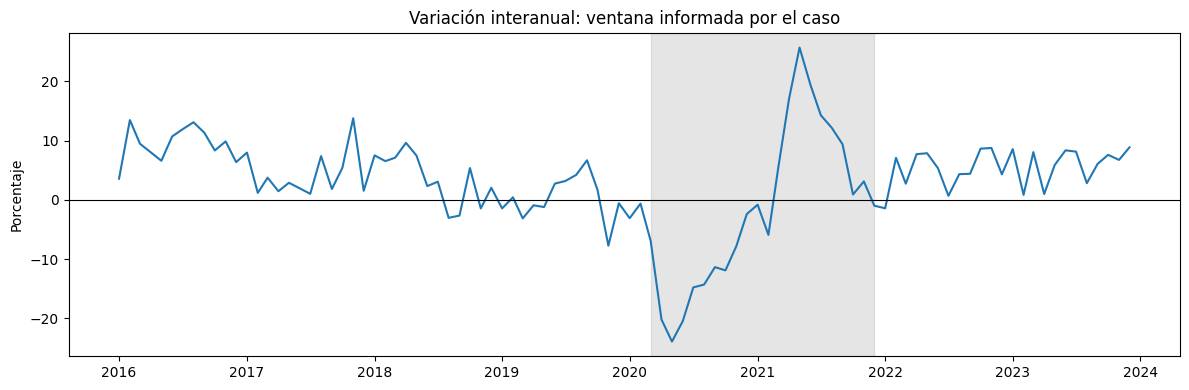

,variacion_pct
fecha,
2019-01-01,-1.44
2019-02-01,0.43
2019-03-01,-3.12
2019-04-01,-0.91
2019-05-01,-1.21
2019-06-01,2.75
2019-07-01,3.19
2019-08-01,4.22
2019-09-01,6.68


,observado_gwh,contrafactual_gwh,brecha_gwh,desviacion_pct
fecha,,,,
2020-03-01,98.20,112.21,14.01,-12.49
2020-04-01,78.15,103.09,24.94,-24.19
2020-05-01,73.19,102.46,29.27,-28.57
2020-06-01,80.60,106.74,26.14,-24.49
2020-07-01,90.00,110.16,20.16,-18.30
2020-08-01,89.17,108.99,19.82,-18.18
2020-09-01,87.62,104.30,16.68,-16.00
2020-10-01,90.38,106.27,15.89,-14.96
2020-11-01,99.72,120.33,20.61,-17.13


Brecha neta en ventana informada (GWh): 373.5477124921494
Finales de secuencias candidatas de retorno: []


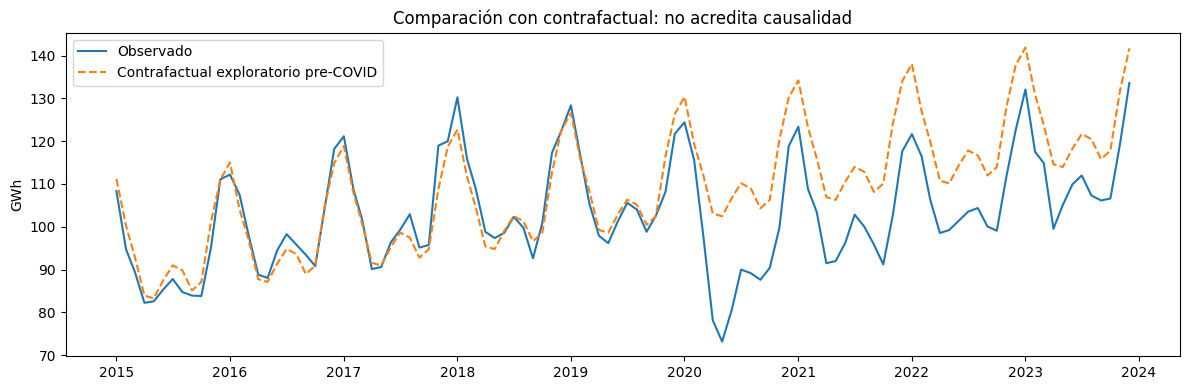

,fecha_actual,fecha_comparada
62,2020-03-01,2019-03-01
63,2020-04-01,2019-04-01
64,2020-05-01,2019-05-01
65,2020-06-01,2019-06-01
66,2020-07-01,2019-07-01
67,2020-08-01,2019-08-01
68,2020-09-01,2019-09-01
69,2020-10-01,2019-10-01
70,2020-11-01,2019-11-01
71,2020-12-01,2019-12-01


In [8]:
# variación interanual y ventana informada: fechas finales por justificar
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(variacion_interanual)
ax.axhline(0, color='black', linewidth=.8)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='gray', alpha=.2)
ax.set(title='Variación interanual: ventana informada por el caso', ylabel='Porcentaje')
mostrar_figura(fig, 's1_covid_interanual.png')
display(variacion_interanual.loc['2019':'2023'].to_frame('variacion_pct'))
# contrafactual exploratorio: patrón por mes y tendencia lineal estimados SOLO antes de 2020-03
pre = serie.loc[:'2020-02-01']
t = np.arange(len(serie), dtype=float)
# crear indicadores para representar el patrón mensual
meses = pd.get_dummies(serie.index.month, drop_first=True, dtype=float).to_numpy()
X = np.column_stack([np.ones(len(serie)), t, meses])
# estimar los coeficientes con los datos previos a marzo de 2020
beta = np.linalg.lstsq(X[:len(pre)], pre.to_numpy(), rcond=None)[0]
# extender ese patrón al período completo para comparar
contrafactual = pd.Series(X @ beta, index=serie.index)
ventana = (serie.index >= '2020-03-01') & (serie.index <= '2021-12-01')
evidencia_covid = pd.DataFrame({'observado_gwh': serie, 'contrafactual_gwh': contrafactual})
# calcular la diferencia entre el consumo de referencia y el observado
evidencia_covid['brecha_gwh'] = evidencia_covid['contrafactual_gwh']-evidencia_covid['observado_gwh']
evidencia_covid['desviacion_pct'] = 100*(serie/contrafactual-1)
display(evidencia_covid.loc[ventana])
print('Brecha neta en ventana informada (GWh):', evidencia_covid.loc[ventana, 'brecha_gwh'].sum())
# candidato descriptivo de retorno: 3 meses seguidos dentro de ±5% del contrafactual
# umbral configurable, no fecha definitiva ni estimación causal
UMBRAL_PCT = 5
MESES_RETORNO = 3
cercano = evidencia_covid['desviacion_pct'].abs() <= UMBRAL_PCT
# buscar tres meses seguidos dentro del margen definido
retorno = cercano.rolling(MESES_RETORNO).sum().eq(MESES_RETORNO)
candidatos = retorno.loc['2020-03-01':]
print('Finales de secuencias candidatas de retorno:', candidatos.index[candidatos].strftime('%Y-%m').tolist())
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(serie, label='Observado')
ax.plot(contrafactual, '--', label='Contrafactual exploratorio pre-COVID')
ax.set(ylabel='GWh', title='Comparación con contrafactual: no acredita causalidad')
ax.legend()
mostrar_figura(fig, 's1_covid_contrafactual.png')
# comparación estacional para anticipar distorsiones en los bordes del shock
bordes = pd.DataFrame({'fecha_actual':serie.index,
    'fecha_comparada':serie.index-pd.DateOffset(months=12)})
en_shock = lambda d: (d >= pd.Timestamp('2020-03-01')) & (d <= pd.Timestamp('2021-12-01'))
cruza = en_shock(bordes['fecha_actual']) != en_shock(bordes['fecha_comparada'])
display(bordes.loc[cruza & (bordes['fecha_comparada'] >= serie.index.min())])


### 5.3 Incorporación de clientes y análisis de covariables — Decisión 1.5

En abril de 2019 aumentan los clientes en 1.059 respecto de marzo, más que en los meses vecinos. Coincide con el evento informado, pero no demuestra un aumento proporcional del consumo.

La correlación del consumo con la temperatura es 0,686. El máximo de verano coincide con temperaturas altas y el máximo local de julio con temperaturas bajas. La refrigeración y la calefacción son posibles explicaciones del caso, aunque los gráficos no separan sus efectos ni prueban una relación lineal única.

La correlación con clientes es 0,319 y con días hábiles 0,016. Clientes y consumo comparten una evolución temporal, sin que esto pruebe causalidad. Una correlación baja tampoco descarta un efecto oculto por otros patrones.

Mantengo el enfoque univariado del curso y uso las covariables como contexto. Para incorporarlas a un modelo futuro habría que conocer o estimar sus valores, especialmente temperatura y clientes.


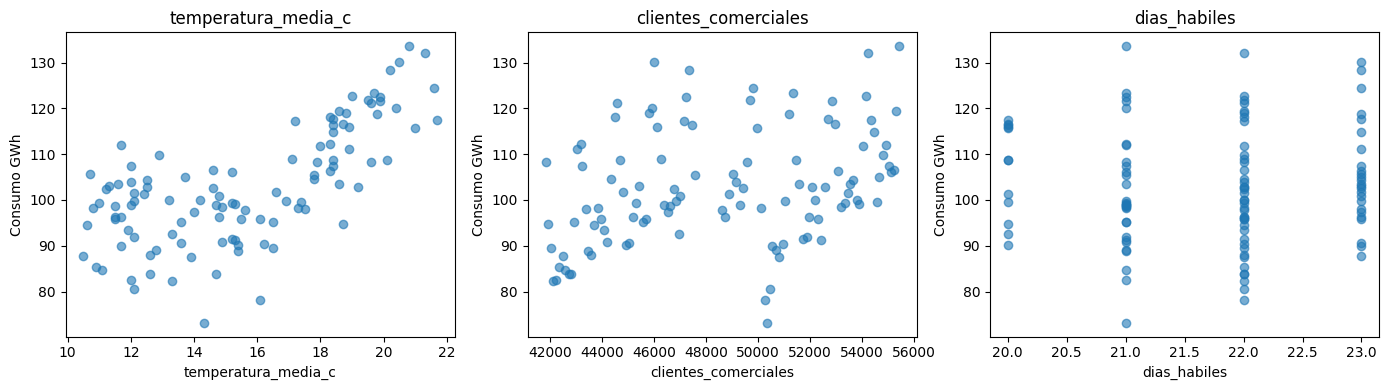

,temperatura_media_c,clientes_comerciales,dias_habiles,consumo_gwh
temperatura_media_c,1.00,0.14,-0.14,0.69
clientes_comerciales,0.14,1.00,0.00,0.32
dias_habiles,-0.14,0.00,1.00,0.02
consumo_gwh,0.69,0.32,0.02,1.00


,temperatura_media_c,clientes_comerciales,dias_habiles,consumo_gwh
fecha,,,,
1,20.08,47906.33,22.00,122.41
2,19.37,48017.22,20.11,111.28
3,17.57,48146.56,22.44,102.94
4,15.33,48364.22,21.22,91.74
5,13.59,48484.44,22.11,91.59
6,11.74,48599.00,21.67,96.04
7,11.30,48720.89,21.89,100.18
8,12.06,48836.67,22.33,98.70
9,13.58,48960.78,21.44,94.85


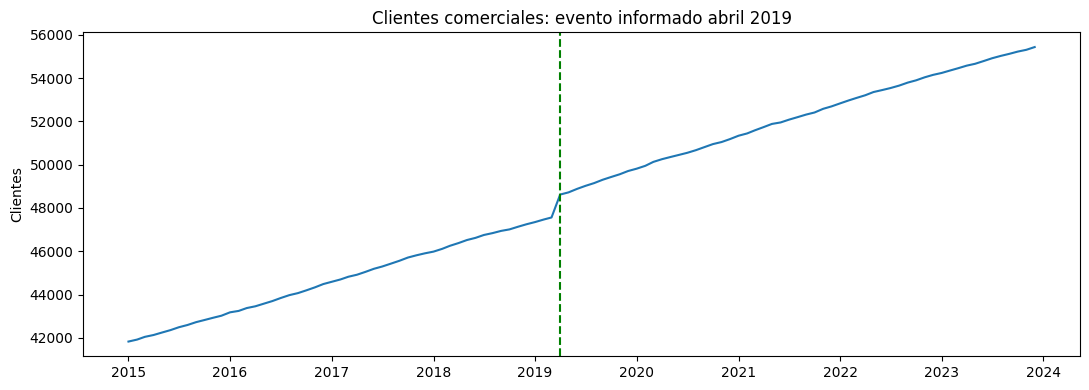

,incremento_mensual
fecha,
2019-01-01,102.00
2019-02-01,117.00
2019-03-01,95.00
2019-04-01,1059.00
2019-05-01,100.00
2019-06-01,163.00
2019-07-01,139.00


In [9]:
# relación con cada covariable: evidencia descriptiva, no causal
variables = ['temperatura_media_c','clientes_comerciales','dias_habiles']
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, var in zip(axes,variables):
    ax.scatter(df[var], serie, alpha=.6)
    ax.set(xlabel=var, ylabel='Consumo GWh', title=var)
mostrar_figura(fig, 's1_covariables.png')
# reunir las variables y el consumo para compararlos
evidencia_variables = df[variables].copy()
evidencia_variables['consumo_gwh'] = serie
# revisar las correlaciones entre las variables
display(evidencia_variables.corr())
# comparar los promedios de cada mes
display(evidencia_variables.groupby(evidencia_variables.index.month).mean())
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(df['clientes_comerciales'])
ax.axvline(pd.Timestamp('2019-04-01'),color='green',linestyle='--')
ax.set(title='Clientes comerciales: evento informado abril 2019',ylabel='Clientes')
mostrar_figura(fig,'s1_clientes.png')
# ver el cambio mensual de clientes cerca de abril de 2019
display(df['clientes_comerciales'].diff().loc['2019-01':'2019-07'].to_frame('incremento_mensual'))


## 6. Descomposición e identificación de componentes — ID 1.1

### 6.1 Justificación del método y período

Elijo la descomposición multiplicativa porque la amplitud relativa ronda el 30 % en varios años, aunque cambia el nivel del consumo. Considero las excepciones de 2020 y 2022 y comparo con el esquema aditivo.

Uso un período de 12 meses por la repetición anual. La serie tiene valores positivos y nueve años completos. El esquema multiplicativo expresa el consumo como tendencia × estacionalidad × residuo; el aditivo suma esos componentes (Hyndman & Athanasopoulos, 2021).

No elijo por la menor varianza residual, porque los residuos de ambos métodos tienen escalas distintas.


In [10]:
# esquema principal multiplicativo y comparación aditiva
# no seleccionar por menor varianza residual: las escalas son diferentes
# separar los componentes usando un período anual
modelos_descomposicion = {
    'Aditivo': seasonal_decompose(serie, model='additive', period=12),
    'Multiplicativo': seasonal_decompose(serie, model='multiplicative', period=12),
}
display(amplitudes[['mean','amplitud_gwh','amplitud_relativa_pct','cv_pct']])
print('Período usado para comparación: 12 meses')


,mean,amplitud_gwh,amplitud_relativa_pct,cv_pct
fecha,,,,
2015,90.78,28.84,31.77,10.84
2016,99.18,30.11,30.36,9.59
2017,103.39,31.01,29.99,10.90
2018,107.09,37.59,35.10,10.95
2019,107.21,32.18,30.02,9.30
2020,95.49,51.21,53.63,17.26
2021,102.15,32.19,31.51,10.02
2022,107.11,24.16,22.56,8.29
2023,113.66,34.05,29.96,9.27


Período usado para comparación: 12 meses


### 6.2 Resultados e interpretación de componentes

La tendencia muestra el aumento general y la caída cercana a 2020. Es un resumen suavizado, no una explicación de sus causas.

Los factores estacionales de enero (1,205) y diciembre (1,159) representan un 20,5 % y 15,9 % sobre el nivel estimado. Abril (0,895) y mayo (0,890) quedan por debajo. Julio tiene un máximo local frente a junio y agosto, aunque su factor (0,971) sigue bajo 1.

El residuo multiplicativo tiene media cercana a 1 y va de 0,856 a 1,070; no se mide en GWh. Estar cerca de 1 no demuestra ruido blanco. En el modelo aditivo, el residuo sí se mide en GWh alrededor de cero.

El filtro centrado deja 12 fechas sin tendencia ni residuo estimados, seis en cada extremo. El método no separa un ciclo independiente ni elimina el efecto de los eventos.


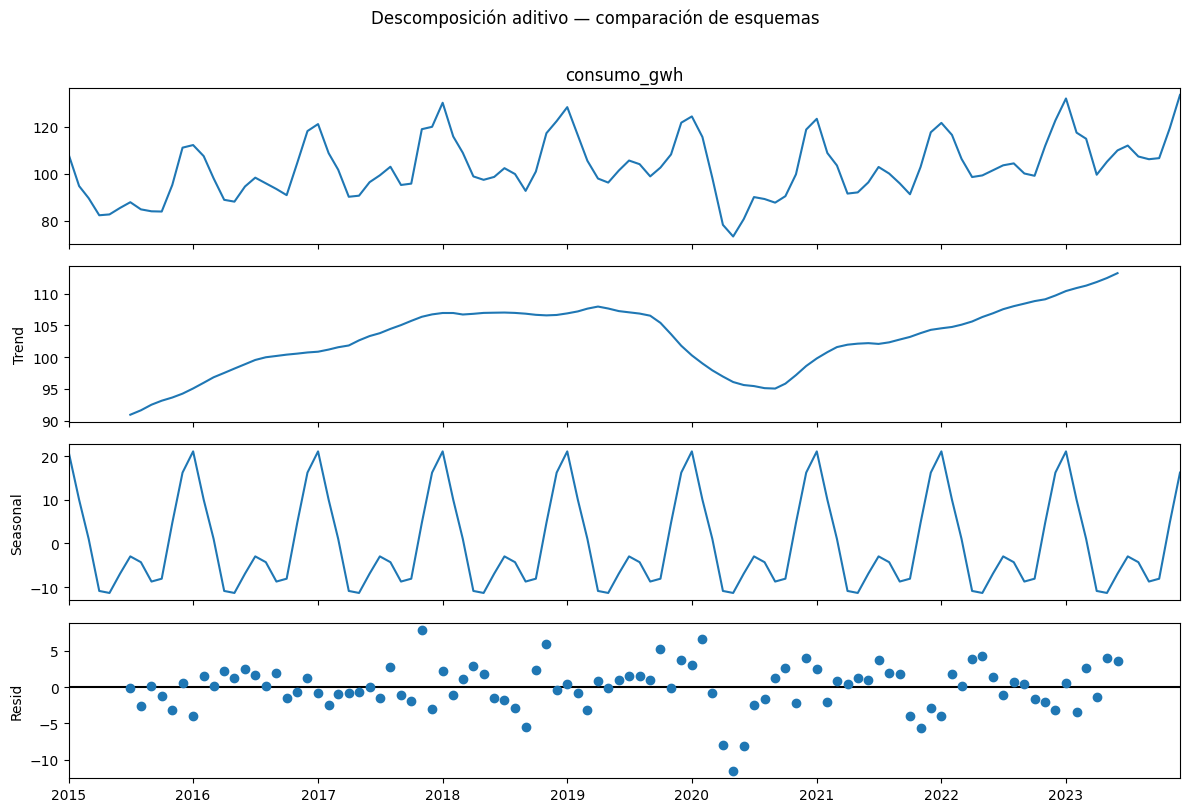

Aditivo


,count,mean,std,min,25%,50%,75%,max
tendencia,96.00,102.98,5.13,90.94,99.74,103.69,106.91,113.21
estacionalidad,108.00,0.00,10.44,-11.33,-8.23,-3.62,6.05,21.09
residuo,96.00,-0.01,3.05,-11.56,-1.67,0.16,1.76,7.89


Tendencias sin estimación: 12


,componente_por_mes
fecha,
1,21.09
2,10.02
3,1.05
4,-10.87
5,-11.33
6,-6.91
7,-2.95
8,-4.28
9,-8.72


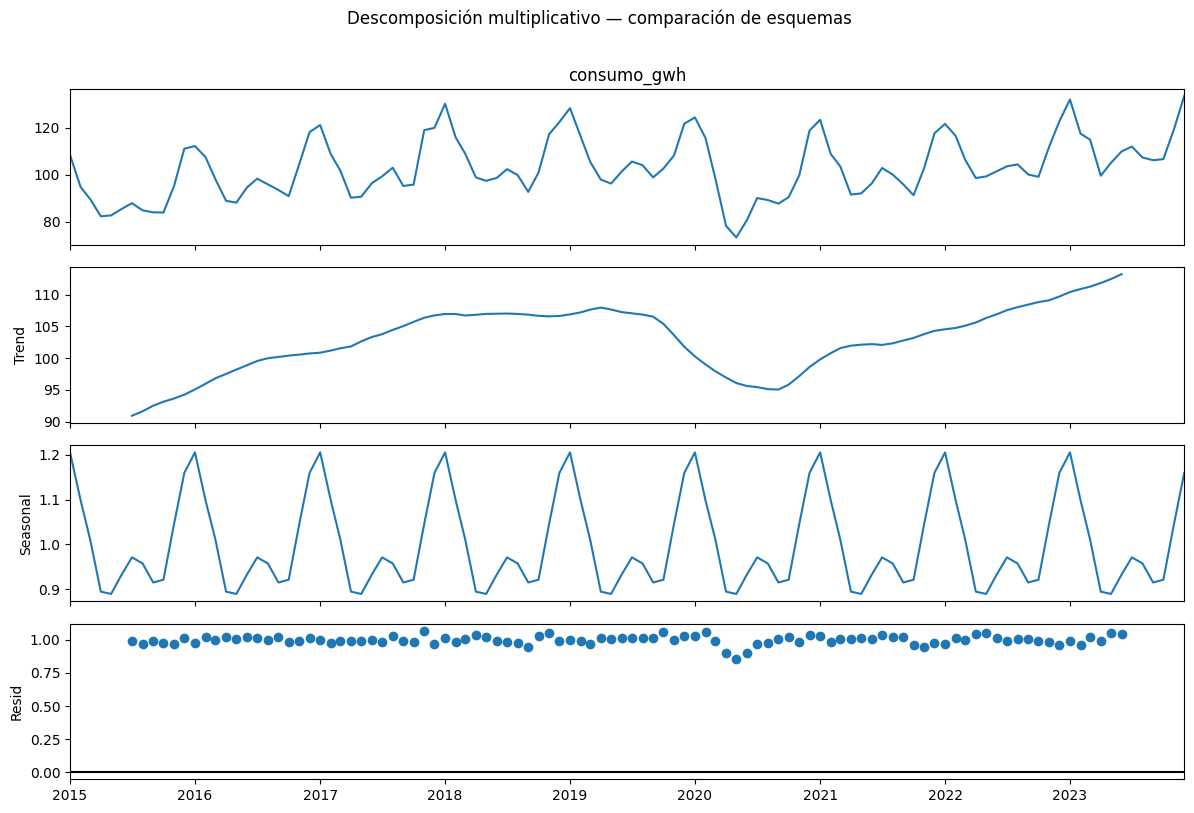

Multiplicativo


,count,mean,std,min,25%,50%,75%,max
tendencia,96.00,102.98,5.13,90.94,99.74,103.69,106.91,113.21
estacionalidad,108.00,1.00,0.10,0.89,0.92,0.96,1.06,1.21
residuo,96.00,1.00,0.03,0.86,0.98,1.00,1.02,1.07


Tendencias sin estimación: 12


,componente_por_mes
fecha,
1,1.21
2,1.10
3,1.01
4,0.89
5,0.89
6,0.93
7,0.97
8,0.96
9,0.92


In [11]:
# mostrar componentes de ambos esquemas sin una selección definitiva
for nombre, resultado in modelos_descomposicion.items():
    fig = resultado.plot()
    fig.set_size_inches(12,8)
    fig.suptitle(f'Descomposición {nombre.lower()} — comparación de esquemas', y=1.01)
    mostrar_figura(fig, f's1_descomposicion_{nombre.lower()}.png')
    # reunir los componentes para revisar sus estadísticas
    componentes = pd.DataFrame({'tendencia':resultado.trend,
        'estacionalidad':resultado.seasonal,'residuo':resultado.resid})
    print(nombre)
    display(componentes.describe().T)
    # contar los meses donde no se pudo estimar la tendencia
    print('Tendencias sin estimación:', resultado.trend.isna().sum())
    # resumir el componente estacional por mes
    display(resultado.seasonal.groupby(resultado.seasonal.index.month).mean().to_frame('componente_por_mes'))


## 7. Análisis de autocorrelación: ACF y PACF — ID 1.2

### 7.1 Cálculo y gráficos

Calculo la ACF y la PACF en niveles, con 36 rezagos, bandas aproximadas del 95 % y método `ywm` para la PACF. La tabla muestra los coeficientes, sus intervalos y cuáles excluyen cero.

Los uso para describir persistencia y estacionalidad, sin elegir órdenes de modelos. Los interpreto en 7.2.


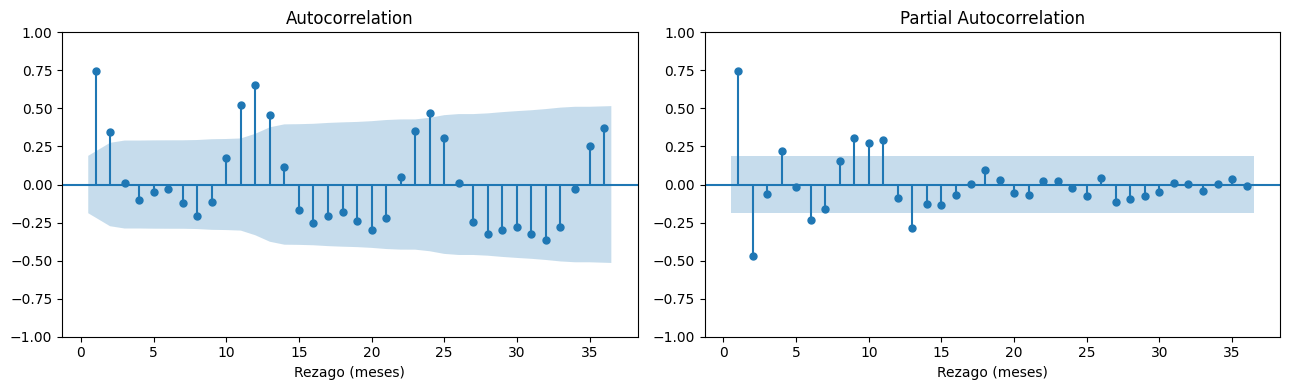

/var/folders/8y/ylcpfmpd5csgjx_p31r99jmw0000gn/T/ipykernel_79378/639157566.py:11: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r_acf, ci_acf = acf(serie, nlags=lags, alpha=.05, fft=False)


,ACF,ACF_inf,ACF_sup,PACF,PACF_inf,PACF_sup,ACF_excluye_cero,PACF_excluye_cero
rezago,,,,,,,,
1,0.74,0.56,0.93,0.74,0.56,0.93,True,True
2,0.35,0.07,0.62,-0.47,-0.66,-0.28,True,True
3,0.01,-0.28,0.30,-0.06,-0.25,0.13,False,False
4,-0.10,-0.39,0.19,0.22,0.03,0.41,False,True
5,-0.05,-0.34,0.24,-0.01,-0.20,0.17,False,False
6,-0.03,-0.32,0.26,-0.23,-0.42,-0.05,False,True
7,-0.12,-0.41,0.17,-0.16,-0.35,0.03,False,False
8,-0.21,-0.50,0.09,0.16,-0.03,0.35,False,False
9,-0.12,-0.41,0.18,0.31,0.12,0.50,False,True


In [12]:
# ACF/PACF en niveles: evidencia, sin seleccionar órdenes de modelos
# limitar los rezagos según la cantidad de datos
lags = min(36, len(serie)//2 - 1)
fig, axes = plt.subplots(1,2,figsize=(13,4))
# graficar las correlaciones con bandas del 95 %
plot_acf(serie, lags=lags, alpha=.05, zero=False, ax=axes[0])
plot_pacf(serie, lags=lags, method='ywm', alpha=.05, zero=False, ax=axes[1])
for ax in axes: ax.set_xlabel('Rezago (meses)')
mostrar_figura(fig,'s1_acf_pacf.png')
# obtener los coeficientes y sus intervalos para la tabla
r_acf, ci_acf = acf(serie, nlags=lags, alpha=.05, fft=False)
r_pacf, ci_pacf = pacf(serie, nlags=lags, method='ywm', alpha=.05)
rezagos = np.arange(1,lags+1)
# organizar los resultados por rezago
correlograma = pd.DataFrame({'ACF':r_acf[1:], 'ACF_inf':ci_acf[1:,0],
    'ACF_sup':ci_acf[1:,1], 'PACF':r_pacf[1:],
    'PACF_inf':ci_pacf[1:,0], 'PACF_sup':ci_pacf[1:,1]},index=rezagos)
correlograma.index.name = 'rezago'
# marcar los intervalos que no incluyen el cero
correlograma['ACF_excluye_cero'] = (correlograma.ACF_inf>0)|(correlograma.ACF_sup<0)
correlograma['PACF_excluye_cero'] = (correlograma.PACF_inf>0)|(correlograma.PACF_sup<0)
display(correlograma)
# intervalos puntuales aproximados; no son prueba simultánea ni evidencia causal


### 7.2 Interpretación de persistencia, estacionalidad y dependencia

La ACF del rezago 1 es alta y positiva (0,745): hay dependencia entre meses consecutivos. Los intervalos del 95 % excluyen cero en los rezagos 1, 2, 11, 12, 13 y 24.

Los rezagos 12 (0,652) y 24 (0,468) apoyan el patrón anual. El 36 es positivo (0,369), pero su intervalo incluye cero y no resulta significativo con este criterio.

La PACF controla los rezagos intermedios. Sobresalen 1, 2, 4, 6, 9, 10, 11 y 13. El rezago 1 es positivo (0,745) y el 2 negativo (−0,469); este signo describe la asociación parcial, no un consumo negativo.

La tendencia, los cambios de nivel y la imputación pueden afectar los resultados. Las bandas son aproximadas y se revisan por rezago. No concluyo estacionariedad ni elijo órdenes de modelos, siguiendo la distinción del material docente (Universidad Andrés Bello, s. f.-b).


## 8. Interpretación técnica integrada y decisiones — ID 1.2

### 8.1 Síntesis de evidencias

El gráfico de 4.1 muestra un aumento general, una caída en 2020 y recuperación posterior, sin probar una tendencia determinista. El perfil de 4.2 repite máximos en diciembre y enero, y uno menor en julio. La descomposición de 6.2 separa tendencia, estacionalidad y residuo. No encuentro un ciclo plurianual claro; trato la caída de 2020 como una perturbación según el caso.

La ACF de 7.1 respalda la dependencia entre meses y el patrón anual, sobre todo en los rezagos 12 y 24. La PACF controla los rezagos intermedios. Interpreto ambas considerando las imputaciones y los eventos.

Las covariables de 5.3 aportan contexto: las correlaciones son 0,686 con temperatura, 0,319 con clientes y 0,016 con días hábiles. No prueban causalidad ni permiten descartar una variable solo por una correlación baja.


### 8.2 Registro de decisiones de Semana 1

Resumo las decisiones y sus efectos para la siguiente etapa.

| Decisión | Tratamiento | Evidencia | Alternativa y consecuencia |
|---|---|---|---|
| 1.1 Imputación | Interpolo los tres huecos y conservo los originales. | Comparación estacional y gráficos de 3.3. | La opción estacional sirve de contraste. Interpolar puede suavizar la serie y cambiar la ACF; son valores estimados. |
| 1.2 Atípico 2017-11 | Conservo y marco el registro. | 5.1: 118,96 GWh y variación de 13,77 %. Ajustarlo cambia la media en −0,075 GWh y la varianza en −1,818 GWh². | No lo reemplazo sin conocer el valor real. La anomalía puede influir en el análisis. |
| 1.3 Período COVID | Mantengo marzo de 2020–diciembre de 2021 como ventana informada. | 5.2: variaciones de −6,91 % en marzo y −23,90 % en mayo de 2020. | El rebote de 2021 no prueba recuperación completa. No aparecen tres meses seguidos dentro de ±5 % del contrafactual. |
| 1.4 Componentes | Identifico cambios de nivel, estacionalidad anual, perturbaciones y residuo. | Gráficos de 4.1–4.3, descomposición de 6.2 y ACF de 7.1. | No afirmo un ciclo plurianual. Consideraré los eventos en el diagnóstico posterior. |
| 1.5 Enfoque | Mantengo el análisis univariado y las covariables como contexto. | 5.3: gráficos, correlaciones y aumento de 1.059 clientes en abril de 2019. | No modelo varias variables aquí; hacerlo requeriría sus valores futuros. |
| Descomposición | Elijo la multiplicativa, con período 12, y comparo con la aditiva. | Amplitudes de 4.3 y componentes de 6.2. | La amplitud relativa apoya la elección, con límites en años perturbados. No comparo directamente las varianzas residuales. |


## 9. Conclusiones, limitaciones y pendientes

### 9.1 Conclusiones

En 2015–2023 identifico cambios de nivel, estacionalidad anual y dependencia temporal. La ACF de los rezagos 12 y 24 coincide con los gráficos y la descomposición. No encuentro un ciclo plurianual claro.

Los tres datos faltantes, el registro de noviembre de 2017 y la caída de 2020 requieren atención. El rebote interanual de 2021 no demuestra una recuperación completa.

Antes de modelar, revisaré la estacionariedad y el efecto de la preparación de los datos. En esta entrega no selecciono un modelo.


### 9.2 Limitaciones y continuidad

- Los tres valores imputados pueden suavizar la serie y cambiar su autocorrelación.
- Los eventos alteran el nivel y pueden afectar la descomposición y los correlogramas.
- La descomposición supone estacionalidad fija, no estima la tendencia en los extremos ni separa un ciclo independiente.
- Las correlaciones no prueban causalidad. El contrafactual depende de sus supuestos y no confirma una recuperación definitiva.

En Semana 2 revisaré la estacionariedad y las posibles transformaciones. Dejo 2024 fuera de estas decisiones, aunque ya lo observé en la formativa.


## 10. Referencias y declaración de apoyo

### 10.1 Referencias bibliográficas

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3rd ed.). OTexts. https://otexts.com/fpp3/

Universidad Andrés Bello. (s. f.-a). *MCDI505 — Análisis de series de tiempo: Caso transversal del curso* [Notebook docente].

Universidad Andrés Bello. (s. f.-b). *MCDI505 — Análisis de series de tiempo* [Notebook docente ejecutado: f1_s01_notebook_series_EJECUTADO.html].

Universidad Andrés Bello. (s. f.-c). *Sumativa 1 — Informe de análisis exploratorio de series de tiempo* [Instrucciones y rúbrica].


### 10.2 Declaración de uso de IA

Usé inteligencia artificial para organizar el notebook, revisar errores de código y mejorar la redacción y la ortografía. Revisé las sugerencias antes de incorporarlas.
